In [1]:
import torch
from torch import nn
from PIL import Image
from torchvision.models.detection.ssd import SSD300_VGG16_Weights
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_Weights

from pathlib import Path

import shutil
import numpy as np
import matplotlib.lines as mlines
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn import metrics
# import matplotlib.patches as patches
from copy import deepcopy
import skimage
from skimage.io import imread
import scipy
# import basicpy
from tqdm import tqdm
import geopandas as gpd
import torchmetrics
import torchmetrics.detection

import models.image_datamodule
import models.embeddings_datamodule
from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp
# from util.cellsam import CellSAM
# from util.umamba import Umamba
# from SSD_model import SSD
from util.samos import SAMOS
# from util.ssd import SSDPredictor
# from util.FasterRCNN import FasterRCNNPredictor
# from util.cellpose import Cellpose
# from util.orgasegment import PredictorFromMasks
# from util.gt_sam import GroundTruthSAM
from util.pred_with_sam import PredictionSAM

%load_ext autoreload
%autoreload 2

In [2]:
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax, color='red'):
    y_min, x_min, y_max, x_max = box
    
    # Calculate width and height of the box
    width = x_max - x_min
    height = y_max - y_min

    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor=color, facecolor=(0,0,0,0), lw=2))

def show_mask(contour, ax, random_color=False, linewidth=0.5):
    if random_color:
        color = np.random.random(3)
    else:
        color = np.array([30/255, 184/255, 255/255])
    edgecolor = np.concatenate([color, np.array([1.0])], axis=0)
    facecolor = np.concatenate([color, np.array([0.1])], axis=0)

    contour = gpd.GeoSeries(contour)
    contour.plot(edgecolor=edgecolor, facecolor=facecolor, ax=ax, linewidth=linewidth)

def visualize(im, contours, boxes, random_color=True, box_color='red', format='yxyx_px', ax=None, **fig_kwargs):
    # Format boxes
    H, W = im.shape[:2]

    if format=='cycxhw_01':
        # boxes are in cycxhw format normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes) * max(H, W)
    elif format=='cycxhw_px':
        # boxes are in cycxhw format in pixels. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes)
    elif format=='yxyx_01':
        # boxes are in min/max coordinates normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = boxes * max(H, W)
    elif format=='yxyx_px':
        # boxes are in min/max coordinates in pixels. No conversion necessary.
        original_boxes = boxes
    else:
        raise ValueError(format)

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kwargs)
    
    ax.imshow(im)
    ax.axis(False)
    for i in range(original_boxes.shape[0]):
        show_mask(contours[i], ax, random_color=random_color)
        show_box(original_boxes[i], ax, color=box_color)

### Figure 2

In [29]:
# base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/OriginalData/testing/images')
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/tmp/example_SAMOS_predictions')

assert base_datadir.exists()
results_dir.mkdir(exist_ok=True)

In [ ]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/tmp/examples_hn/Pictures of Lung organoid 2/Pictures of Lung organoid/211223')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/tmp/examples_hn/Pictures of Lung organoid 2/predictions/211223')

assert base_datadir.exists()
results_dir.mkdir(exist_ok=True)

In [17]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/tmp/examples_hn/Pictures of Lung organoid 2/Pictures of Lung organoid/241123')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/tmp/examples_hn/Pictures of Lung organoid 2/predictions/241123')

assert base_datadir.exists()
results_dir.mkdir(exist_ok=True)

In [4]:
samos = SAMOS()

/ictstr01/groups/peng/datasets/lion/data/venvs/sam_dh/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [5]:
samos.max_detections = 500

In [30]:
images = sorted(list(base_datadir.glob('*.*')))
images

[PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images/b_image0007.png'),
 PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images/b_image0009.png'),
 PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images/image0016.png'),
 PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images/image0017.png')]

In [24]:
for file in tqdm(images):
    im = cv2.imread(file)
    im, flatfield = dl.normalize(im, correct_bg=True, grayscale=True)
    contours, boxes, scores = samos.forward(im, patch_size=(1024, 2048), min_diameter=10)
    for score in [0.9, 0.95]:
        contours, boxes, scores = samos.set_threshold(score)

        # Plot predictions with masks
        fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
        ax.imshow(im)
        for i in range(boxes.shape[0]):
            show_mask(contours[i], ax, random_color=True, linewidth=0.8)
        ax.axis(False)
        plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)
        fig.savefig(results_dir / f'prediction_score_{score}_{file.stem}.png', dpi=400, bbox_inches='tight')
        plt.close('all')
        
        # Plot boxes only
        fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
        ax.imshow(im)
        ax.axis(False)
        plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)
        fig.savefig(results_dir / f'box_prediction_score_{score}_{file.stem}.png', dpi=400, bbox_inches='tight')
        plt.close('all')

  0%|                                                                                                                                | 0/30 [00:00<?, ?it/s]

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
len(self.pred_scores) 600


  3%|████                                                                                                                    | 1/30 [00:16<07:54, 16.36s/it]

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
len(self.pred_scores) 600


  7%|████████                                                                                                                | 2/30 [00:32<07:26, 15.94s/it]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 28/30 [08:02<00:33, 16.97s/it]

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
len(self.pred_scores) 600


 97%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████    | 29/30 [08:17<00:16, 16.58s/it]

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
len(self.pred_scores) 600


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [08:34<00:00, 17.15s/it]


In [31]:
file = images[3]
file

PosixPath('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/OrganoID/MouseOrganoids/testing/images/image0017.png')

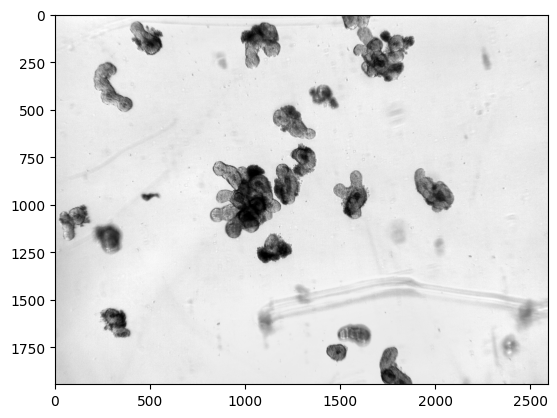

In [32]:
im = cv2.imread(file)
im, flatfield = dl.normalize(im, correct_bg=True, grayscale=True)

plt.imshow(im)

In [33]:
contours, boxes, scores = samos.forward(im, patch_size=(1024, 2048), min_diameter=10)

torch.Size([1, 256, 64, 64])
patch 0
torch.Size([1, 256, 64, 64])
patch 1
torch.Size([1, 256, 64, 64])
patch 2
torch.Size([1, 256, 64, 64])
patch 3
torch.Size([1, 256, 64, 64])
patch 4
torch.Size([1, 256, 64, 64])
patch 5
torch.Size([1, 256, 64, 64])
patch 6
torch.Size([1, 256, 64, 64])
patch 7
torch.Size([1, 256, 64, 64])
patch 8
torch.Size([1, 256, 64, 64])
patch 9
torch.Size([1, 256, 64, 64])
patch 10
torch.Size([1, 256, 64, 64])
patch 11
torch.Size([1, 256, 64, 64])
patch 12
torch.Size([1, 256, 64, 64])
patch 13
torch.Size([1, 256, 64, 64])
patch 14
torch.Size([1, 256, 64, 64])
patch 15
torch.Size([1, 256, 64, 64])
patch 16
len(self.pred_scores) 5100


In [57]:
contours, boxes, scores = samos.set_threshold(0.97)

In [58]:
boxes, len(boxes)

(array([[  41.77288055,  390.84393311,  212.69036865,  569.72937012],
        [ 803.67303467, 1873.64123535, 1032.63793945, 2102.72106934],
        [ 798.35107422, 1461.15136719, 1079.16259766, 1659.67480469],
        [1625.44317627, 1476.25564575, 1750.35748291, 1663.43984985],
        [1148.23046875, 1046.8274231 , 1306.10974121, 1245.23379517],
        [ 473.81906128, 1134.59967041,  663.26812744, 1380.67633057],
        [1548.42492676,  230.95883179, 1703.10095215,  386.45944214],
        [1107.62426758,  204.9312439 , 1272.02416992,  351.92733765],
        [1721.15283203, 1418.99926758, 1823.91113281, 1537.99926758],
        [ 756.0222168 ,  778.47245789, 1181.5814209 , 1226.02575684],
        [1733.4576416 , 1701.16479492, 1952.77697754, 1873.52685547],
        [  46.34634399, 1543.92077637,  356.30181885, 1864.23693848],
        [ 235.19773865,  176.00332642,  536.40087891,  394.86477661],
        [  43.50683594,  960.21972656,  284.55560303, 1193.13830566],
        [ 675.288345

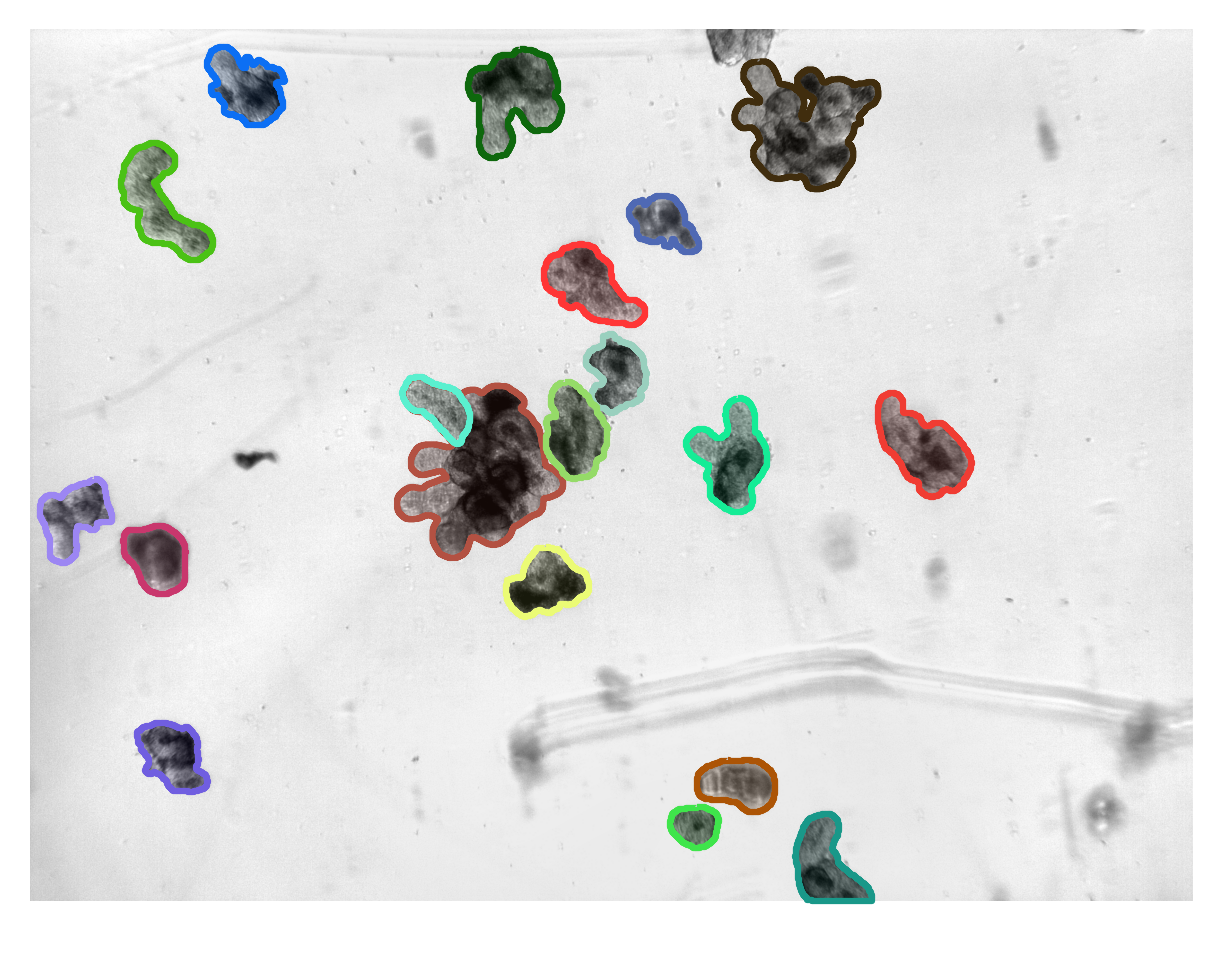

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

# Plot mask predictions
ax.imshow(im)
for i in range(boxes.shape[0]):
    show_mask(contours[i], ax, random_color=True, linewidth=1.5)
ax.axis(False)

# plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False)

fig.savefig(results_dir / f'prediction_{file.stem}.png', dpi=400, bbox_inches='tight')